# Acquisition notebook

This notebook is split between:
- **run cells** here
- reusable helpers in the `utils/` Python files next to the notebook

The goal is to keep this notebook readable and focused on experiments.

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import serial
import pyvisa as pv

In [2]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from datetime import datetime
from pathlib import Path

In [3]:
from utils.oc3 import OC3

from utils.temperature import (
    generate_temperature_list,
    wait_for_stable_temperature,
    wait_for_user_popup,
    finalize_oc3,
)

In [4]:
DATA_DIR = "data/data_temp_SHG"
os.makedirs(DATA_DIR, exist_ok=True)

In [5]:
wavelength = 780e-6 # wavelength in microns!

In [6]:
# Check available VISA resources
rm = pv.ResourceManager()
print(rm.list_resources())

# # Check available serial ports (for OC3)
# ports = serial.tools.list_ports.comports()
# for p in ports:
#     print(p.device, p.description)


('USB0::0x0699::0x039F::C010359::INSTR', 'USB0::0x1313::0x8079::P1007388::INSTR', 'ASRL1::INSTR', 'ASRL3::INSTR')


## Temperature sweep with PM100A + OC3

This run:
- connects the PM100A for power reading
- uses the OC3 for temperature control
- waits for stabilization
- optionally asks for manual lock confirmation
- reads one or several PM100A values per temperature
- saves one CSV per temperature and one summary CSV

In [7]:
# FOLDER
TEMP_SCAN_DIR = os.path.join(DATA_DIR, "temperature_scan")
RUN_NAME = time.strftime("temp_scan %m %d")
RUN_DIR = os.path.join(DATA_DIR, RUN_NAME)
os.makedirs(RUN_DIR, exist_ok=True)

print("Temperature scan data will be saved in:", RUN_DIR)

Temperature scan data will be saved in: data/data_temp_SHG\temp_scan 05 04


In [8]:
# Connect to PM100A power meter via PyVISA
pm100a = rm.open_resource('USB0::0x1313::0x8079::P1007388::INSTR')
print(pm100a.query('*IDN?'))

Thorlabs,PM100A,P1007388,2.5.0



In [9]:
# Connect to OC3 temperature controller via pyserial
OC_PORT = "COM3" 
oc3 = OC3(port=OC_PORT)
print("Connected to OC3 on port", OC_PORT, oc3.status())

Connected to OC3 on port COM3 b'j5543.500;43.496;1;05.4;0;0;1;24.046;c24/1.54p;0;0;43.500;6C'


In [10]:
ASK_USER_CONFIRMATION = False

# TEMPERATURE CONTROL
TEMP_START = 43.5
TEMP_END = 46.5
TEMP_STEP = 0.1
RAMP_RATE = 0.05

TEMP_TOL = 0.01
STABLE_TIME = 30.0
POLL_INTERVAL = 1.0

# POWER-METER
PM_SAMPLES_PER_POINT = 20
PM_SAMPLE_DELAY = 0.1

PM_RECORD_DURATION = 1          # seconds
PM_SAMPLE_DELAY = 0.1          # seconds between reads
PM_USE_FETCH = False           # False -> READ?, True -> FETCh?
PM_AVERAGE_COUNT = 1           # instrument-side averaging

In [ ]:
# PM100A Record series
def record_pm100a(ressource, duration_s=10.0, dt_s=0.1):
    """
    Record power meter readings for a specified duration and sampling interval.
    :param ressource: PyVISA instrument handle for the PM100A power meter
    :param duration_s: Total recording duration in seconds
    :param dt_s: Time interval between consecutive readings in seconds

    :return: Tuple of (mean power in mW, error on the mean in mW)
    """
    t0 = time.time()

    times = []
    values_mW = []

    while time.time() - t0 < duration_s:
        t = time.time() - t0
        raw_value = ressource.query("READ?")  # Get raw reading from the instrument
        # print(raw_value)
        value_mW = float(raw_value[:-1]) * 1e3  # Convert from W to mW (assuming raw_value ends with 'W')
        # print(value_mW)
        times.append(t)
        values_mW.append(value_mW)

        time.sleep(dt_s)

    times = np.array(times)
    values_mW = np.array(values_mW)

    mean_mW = np.mean(values_mW)
    std_mW = np.std(values_mW, ddof=1)
    error_mW = std_mW / np.sqrt(len(values_mW))  # error on the mean

    return mean_mW, error_mW

INFO:1:2026_05_04__17_22_33__temperature_scan


Temperature list: [43.5, 43.6, 43.7, 43.8, 43.9, 44.0, 44.1, 44.2, 44.3, 44.4, 44.5, 44.6, 44.7, 44.8, 44.9, 45.0, 45.1, 45.2, 45.3, 45.4, 45.5, 45.6, 45.7, 45.8, 45.9, 46.0, 46.1, 46.2, 46.3, 46.4, 46.5]

Point 1/31  |  Set temperature = 43.500 °C
Current T: 43.501  ± 0.001 °C
3.78502336E-05

0.0378502336
7.33807610E-05

0.073380761
4.37715207E-05

0.043771520700000004
4.37715207E-05

0.043771520700000004
2.15505672E-04

0.215505672
4.96956127E-05

0.0496956127
4.96956127E-05

0.0496956127
8.52261437E-05

0.0852261437
3.19289466E-05

0.0319289466
9.70687179E-05

0.0970687179
6.15381869E-05

0.0615381869
7.93020517E-05

0.0793020517
4.37715207E-05

0.043771520700000004
8.52261437E-05

0.0852261437
6.15381869E-05

0.0615381869
5.56168998E-05

0.0556168998
4.96956127E-05

0.0496956127
4.37715207E-05

0.043771520700000004
6.74594776E-05

0.0674594776
2.00863742E-05

0.0200863742
Mean power = 0.064795 ± 0.009068 mW

Point 2/31  |  Set temperature = 43.600 °C
Current T: 43.537  ± 0.003 °C
1

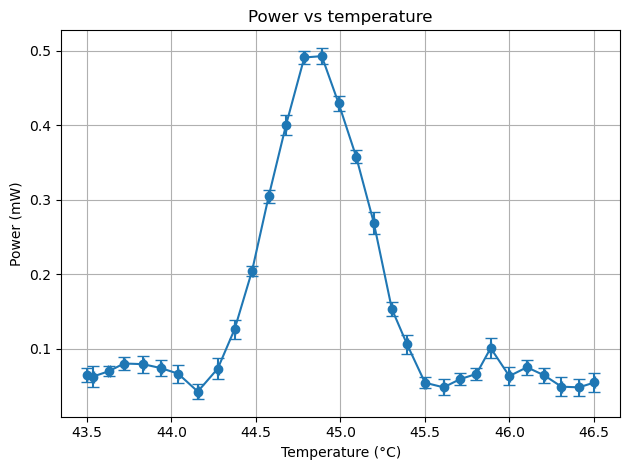

In [12]:
aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell("temperature_scan")

temps = generate_temperature_list(TEMP_START, TEMP_END, TEMP_STEP)
scan_results = []

PM_RECORD_DURATION = 5      # seconds
oc3.enable()

print("Temperature list:", temps)
list_SHG_powers , list_SHG_errors = [] , []
list_Tmeas , list_Terrors = [] , []
for i, T in enumerate(temps, start=1):
    print("\n" + "=" * 60)
    print(f"Point {i}/{len(temps)}  |  Set temperature = {T:.3f} °C")
    print("=" * 60)

    oc3.set_temperature(T, ramp=RAMP_RATE)
    time.sleep(10)

    Tmeas, Terror = oc3.get_mean_temperature(duration_s=4.0)
    print(f"Current T: {Tmeas:.3f}  ± {Terror:.3f} °C")

    mean_mW, error_mW = record_pm100a(
        pm100a,
        duration_s=2,
        dt_s=PM_SAMPLE_DELAY
    )
    list_SHG_powers.append(mean_mW)
    list_SHG_errors.append(error_mW)
    list_Tmeas.append(Tmeas)
    list_Terrors.append(Terror)
    print(f"Mean power = {mean_mW:.6f} ± {error_mW:.6f} mW")



oc3.set_temperature(temps[0], ramp=RAMP_RATE)
time.sleep(5)
plt.errorbar(list_Tmeas, list_SHG_powers, xerr = list_Terrors, yerr = list_SHG_errors , fmt="o-", capsize=4)
plt.xlabel("Temperature (°C)")
plt.ylabel("Power (mW)")
plt.title("Power vs temperature")
plt.grid(True)
plt.tight_layout()
plt.show()


aqm.save_acquisition(list_Tmeas=list_Tmeas, list_SHG_powers=list_SHG_powers, list_SHG_errors=list_SHG_errors, list_Terrors=list_Terrors , pump_power_mW = 300)

In [ ]:
print(RUN_DIR)
aqm = AcquisitionAnalysisManager(RUN_DIR)
data_name = "temperature_scan_summary"
print(data_name)
aqm.acquisition_cell(data_name)

df_scan = pd.DataFrame(scan_results)
aqm.save_acquisition(
    acquisition_type="scan_status",
    status="interrupted",
    scan=scan_results,
)

INFO:1:2026_04_28__16_51_36__temperature_scan_summary


data/data_temp_SHG/temp_scan 04 28
temperature_scan_summary
